# Get the brain data

In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import os

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as st
import scvi
import seaborn as sns
from anndata import AnnData
from rich import print

import nichevi

scvi.settings.seed = 34

Global seed set to 34


In [74]:
from dataclasses import dataclass
from typing import Optional


@dataclass(frozen=True)
class PARAMS:
    """set all params for our analysis"""

    # DATA_FOLDER: str = (
    #     "/home/labs/nyosef/Collaboration/SpatialDatasets/xenium/human_breast_cancer/"
    # )
    DATA_FOLDER: str = "/home/nathanlevy/sda/Data/"

    # DATA_FILE: str = "xenium_breast_cancer_S1_R1_2.h5ad"
    DATA_FILE: str = "adata_M1_M2_core_6_sections.h5ad"

    # for the data
    COORDS: str = "spatial"
    BATCH: str = "brain_section_label"
    SAMPLE: str = "brain_section_label"
    CELL_TYPE: str = "cell_type"
    NICHE: str = "major_brain_region"

    # for scVI
    N_LAYERS: int = 1
    N_LATENT: int = 10
    LIKELIHOOD: str = "poisson"
    ######################
    N_EPOCHS_SCVI: int = 400
    BATCH_SIZE: int = 128
    OPTIMIZER: str = "Adam"
    ######################
    WEIGHT_DECAY: float = 1e-6
    KL_WARMUP: Optional[int] = None

    # for nicheVI
    K_NN: int = 20  # TODO try also less cells per niche, like 12
    N_LAYERS_NICHE: int = 1
    N_LAYERS_COMPO: int = 1
    N_HIDDEN: int = 128
    N_HIDDEN_COMPO: int = 128  # TODO make it adaptable
    N_HIDDEN_NICHE: int = 128
    N_LATENT_NICHEVI: int = 10
    ATTENTION_DECODER: bool = True
    N_HEADS: int = 2
    ######################
    N_EPOCHS_NICHEVI: int = 400
    REDUCE_LR_ON_PLATEAU: bool = True
    LR: float = 1e-4
    SPATIAL_WARMUP: Optional[int] = 10
    MIN_SPATIAL_WEIGHT: float = 1.0
    MAX_SPATIAL_WEIGHT: float = 10

    # +batch norm/layer norm

    CELL_TYPES_FOR_NICHES = None

    CELL_TYPES_FOR_STRATIFICATION = [
        # "DCIS_2",
        "Macrophages_1",
        # "Unlabeled",
        # "Invasive_Tumor",
        # "Stromal",
        # "DCIS_1",
        # "Myoepi_ACTA2+",
        "CD8+_T_Cells",
        # "Endothelial",
        # "Prolif_Invasive_Tumor",
        # "T_Cell_&_Tumor_Hybrid",
        # "Mast_Cells",
        "CD4+_T_Cells",
        "B_Cells",
        "Macrophages_2",
        # "Stromal_&_T_Cell_Hybrid",
        # "Perivascular-Like",
        "LAMP3+_DCs",  # PUT THE DCS TOGETHER
        "IRF7+_DCs",
        # "Myoepi_KRT15+",
    ]


setup = PARAMS()

In [75]:
data_dir, data_file = setup.DATA_FOLDER, setup.DATA_FILE

data_file_name = os.path.splitext(data_file)[0]
print(data_file_name)

path_to_save = os.path.join("../niche-VI-experiments/checkpoints", data_file_name)
os.makedirs(path_to_save, exist_ok=True)

adata = ad.read_h5ad(os.path.join(data_dir, data_file))
print(adata)

adata_M1_M2_core_6_sections

AnnData object with n_obs × n_vars = 250790 × 1122
    obs: 'organism_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 
'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 
'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 
'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 
'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 
'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 
'observation_joinid', 'n_counts', 'batch', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 
'feature_length', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 
'total_counts', 'log1p_total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca', 'simvi_train_mask', 'simvi_train_mask_06', 
'simvi_train_mask_08', 'simvi_val_mask', 'simvi_val_mask_06', 'simvi_val_mask_08'
    obsm: 'X_CCF', 'X_pca', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 
'banksy_pc_20_lambda_0.4', 'banksy_pc_20_lambda_0.5', 'banksy_pc_20_lambda_0.6', 'simvi_both', 'simvi_both_06', 
'simvi_both_07', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_06', 'simvi_both_MDE_07', 'simvi_both_MDE_08', 
'simvi_interact', 'simvi_interact_06', 'simvi_interact_07', 'simvi_interact_08', 'simvi_interact_MDE', 
'simvi_interact_MDE_06', 'simvi_interact_MDE_07', 'simvi_interact_MDE_08', 'simvi_intrinsic', 'simvi_intrinsic_06',
'simvi_intrinsic_07', 'simvi_intrinsic_08', 'simvi_intrinsic_MDE', 'simvi_intrinsic_MDE_06', 
'simvi_intrinsic_MDE_07', 'simvi_intrinsic_MDE_08', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [76]:
adata.var_names = adata.var["gene_name"]

# Run scvi-nichevi

In [77]:
scvi_is_trained = True
nichevi_is_trained = True
save_scvi = True

print("scVI trained: ", scvi_is_trained, "nicheVI trained: ", nichevi_is_trained)


history_setup = {}

if scvi_is_trained is False:
    scvi.model.SCVI.setup_anndata(
        adata,
        layer="counts",
        batch_key=setup.BATCH,
    )

    scvivae = scvi.model.SCVI(
        adata,
        gene_likelihood=setup.LIKELIHOOD,
        n_layers=setup.N_LAYERS,
        n_latent=setup.N_LATENT,
    )

    scvivae.train(
        max_epochs=setup.N_EPOCHS_SCVI,
        train_size=0.8,
        validation_size=0.2,
        batch_size=setup.BATCH_SIZE,
        plan_kwargs={
            "n_epochs_kl_warmup": setup.KL_WARMUP,
            "weight_decay": setup.WEIGHT_DECAY,
            "optimizer": setup.OPTIMIZER,
        },
        # trainer_kwargs=dict(check_val_every_n_epoch=1),
        early_stopping=True,
    )

    if save_scvi:
        scvivae.save(
            dir_path=path_to_save
            + "/scvivae_E"
            + str(setup.N_EPOCHS_SCVI)
            # + "_"
            # + str(setup.N_LAYERS)
            # + "L"
            + ".pt",
            save_anndata=False,
        )

if scvi_is_trained:
    scvivae = scvi.model.SCVI.load(
        dir_path=path_to_save + "/scvivae_E" + str(setup.N_EPOCHS_SCVI) + ".pt",
        adata=adata,
    )

adata.obsm["X_scVI"] = scvivae.get_latent_representation(batch_size=setup.BATCH_SIZE)
# SCVI_MDE_KEY = "X_scVI_MDE"
# adata.obsm[SCVI_MDE_KEY] = scvi.model.utils.mde(adata.obsm["X_scVI"])

# adata.write_h5ad(
#     os.path.join(path_to_save, data_file_name + "_scVI.h5ad"),
# )

history_setup["X_scVI"] = scvivae.history


print("scVI done...")

scVI trained:  True nicheVI trained:  True

INFO     File ../niche-VI-experiments/checkpoints/adata_M1_M2_core_6_sections/scvivae_E400.pt/model.pt already     
         downloaded                                                                                                


/home/nathanlevy/scvi-tools/scvi/model/base/_base_model.py:690: UserWarning: var_names for adata passed in does not match var_names of adata used to train the model. For valid results, the vars need to be the same and in the same order as the adata used to train the model.
  _validate_var_names(adata, var_names)


scVI done...

In [78]:
df_DE_scvi = scvivae.differential_expression(
    groupby=setup.CELL_TYPE,
    group1="microglial cell",
    # group2="CD4+_T_Cells",
    mode="change",
    batch_correction=False,
)

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

DE...: 100%|██████████| 1/1 [00:03<00:00,  3.72s/it]


In [79]:
df_DE_scvi.head(20)

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
gene_name,,,,,,,,,,,,,,,,,,,,,
Ctss,0.9968,0.0032,5.741396,0.096355,0.001296,0.0,0.25,7.087187,7.406014,2.213574,...,10.857529,0.180516,0.937557,0.088203,1036.939819,9.819163,True,microglial cell vs Rest,microglial cell,Rest
Ptprc,0.9966,0.0034,5.680571,0.009187,0.000150,0.0,0.25,7.342382,7.552833,2.476923,...,1.005437,0.024047,0.533402,0.014818,93.799744,1.333998,True,microglial cell vs Rest,microglial cell,Rest
Upk1b,0.9958,0.0042,5.468460,0.003304,0.000065,0.0,0.25,6.003718,6.231408,2.179071,...,0.380287,0.012496,0.218434,0.010443,33.316906,0.576528,True,microglial cell vs Rest,microglial cell,Rest
Fyb,0.9956,0.0044,5.421739,0.013579,0.000195,0.0,0.25,6.877697,7.209885,2.083574,...,1.623911,0.030038,0.651286,0.023641,148.137100,1.702852,True,microglial cell vs Rest,microglial cell,Rest
Lcp1,0.9954,0.0046,5.377086,0.016227,0.000428,0.0,0.25,5.996451,6.136468,2.264230,...,1.715992,0.060671,0.670225,0.043907,170.682724,3.786198,True,microglial cell vs Rest,microglial cell,Rest
Hpgd,0.9948,0.0052,5.253881,0.005219,0.000147,0.0,0.25,5.396398,5.595784,1.869202,...,0.614463,0.024758,0.372590,0.021923,58.156296,1.240417,True,microglial cell vs Rest,microglial cell,Rest
Nfam1,0.9946,0.0054,5.215940,0.008663,0.000197,0.0,0.25,6.457898,6.723786,2.111289,...,1.013009,0.029257,0.537420,0.022228,94.959267,1.546402,True,microglial cell vs Rest,microglial cell,Rest
Tpbgl,0.9944,0.0056,5.179371,0.004207,0.000174,0.0,0.25,5.230368,5.428538,1.952248,...,0.542141,0.032723,0.337466,0.025579,50.987339,1.584548,True,microglial cell vs Rest,microglial cell,Rest
Mafb,0.9940,0.0060,5.109976,0.028546,0.001001,0.0,0.25,5.693702,5.889436,2.107970,...,3.414946,0.191463,0.812672,0.092499,318.884827,8.293403,True,microglial cell vs Rest,microglial cell,Rest


In [80]:
# df_DE_nichevi.head(30)

https://pytorch-lightning.readthedocs.io/en/1.5.10/advanced/profiler.html#built-in-checks

In [81]:
from lightning.pytorch.callbacks import DeviceStatsMonitor

device_stats = DeviceStatsMonitor()
# trainer = Trainer(callbacks=[device_stats])

In [82]:
niche_setup = {
    "scvi_r1_kl1_s10": {
        "cell_rec_weight": 1,
        "latent_kl_weight": 1.0,
        "spatial_weight": 1,
        "n_latent": setup.N_LATENT_NICHEVI,
        "n_layers_niche": setup.N_LAYERS_NICHE,
        "n_layers_compo": setup.N_LAYERS_COMPO,
        "n_hidden_niche": setup.N_HIDDEN_NICHE,
        "n_hidden_compo": setup.N_HIDDEN_COMPO,
        "niche_expression": "scvi",
        "optimizer": setup.OPTIMIZER,
    },
}

In [83]:
for setting in niche_setup.keys():
    print("[bold green]" + setting + "[/bold green]")
    setup_dict = niche_setup[setting]

    # preprocessing function to populate adata.obsm with the keys 'neighborhood_composition',
    # 'qz1_m', 'qz1_var', 'niche_indexes', 'niche_distances', 'qz1_m_niche_knn', 'qz1_var_niche_knn', 'qz1_m_niche_ct',
    # 'qz1_var_niche_ct'

    path_to_save_nichevae = path_to_save + "/nichevae_" + setting + "_" + str(setup.N_EPOCHS_NICHEVI) + ".pt"

    if setup_dict["niche_expression"] == "poisson_counts":
        NICHE_LIKELIHOOD = "poisson"
        adata.obsm["qz1_m"] = adata.layers["counts"]

    if setup_dict["niche_expression"] == "pca":
        NICHE_LIKELIHOOD = "gaussian"
        adata.obsm["qz1_m"] = adata.obsm["X_pca"]

    if setup_dict["niche_expression"] == "scvi":
        NICHE_LIKELIHOOD = "gaussian"
        adata.obsm["qz1_m"] = adata.obsm["X_scVI"]

    if setup_dict["niche_expression"] == "gaussian_counts":
        NICHE_LIKELIHOOD = "gaussian"
        adata.obsm["qz1_m"] = adata.X.toarray()

    nichevi.nicheSCVI.preprocessing_anndata(
        adata,
        niche_composition_key="neighborhood_composition",
        niche_indexes_key="niche_indexes",
        niche_distances_key="niche_distances",
        niche_type_key="niche_type",
        niche_treshold=None,
        cell_type_for_niches=None,
        label_key=setup.CELL_TYPE,
        sample_key=setup.SAMPLE,
        cell_coordinates_key=setup.COORDS,
        k_nn=setup.K_NN,
        latent_mean_key="qz1_m",
        latent_mean_niche_key="qz1_m_niche_ct",
    )

    if setup_dict["niche_expression"] == "poisson_counts":
        adata.obsm["qz1_m_niche_ct"] = np.ceil(adata.obsm["qz1_m_niche_ct"])

    nichevi.nicheSCVI.setup_anndata(
        adata,
        layer="counts",
        batch_key=setup.BATCH,
        labels_key=setup.CELL_TYPE,
        niche_composition_key="neighborhood_composition",
        niche_indexes_key="niche_indexes",
        niche_distances_key="niche_distances",
        latent_mean_key="qz1_m",
        latent_mean_ct_key="qz1_m_niche_ct",
    )

    if nichevi_is_trained is False:
        # check if path_to_save_nichevae exists
        if os.path.exists(path_to_save_nichevae):
            print("Model already exists...")
            # get out of the loop
            continue

        nichevae = nichevi.nicheSCVI(
            adata,
            cell_rec_weight=setup_dict["cell_rec_weight"],
            latent_kl_weight=setup_dict["latent_kl_weight"],
            spatial_weight=setup_dict["spatial_weight"],
            niche_likelihood=NICHE_LIKELIHOOD,
            gene_likelihood=setup.LIKELIHOOD,
            n_layers=setup.N_LAYERS,
            n_heads=setup.N_HEADS,
            n_layers_niche=setup_dict["n_layers_niche"],
            n_layers_compo=setup_dict["n_layers_compo"],
            n_hidden_niche=setup_dict["n_hidden_niche"],
            n_hidden_compo=setup_dict["n_hidden_compo"],
            n_latent=setup_dict["n_latent"],
            use_batch_norm="both",
            use_layer_norm="none",
            attention_decoder=setup.ATTENTION_DECODER,
        )

        nichevae.train(
            max_epochs=setup.N_EPOCHS_NICHEVI,
            train_size=0.8,
            validation_size=0.2,
            early_stopping=True,
            check_val_every_n_epoch=1,
            batch_size=setup.BATCH_SIZE,
            plan_kwargs={
                "lr": setup.LR,
                "n_epochs_kl_warmup": setup.KL_WARMUP,
                "n_epochs_spatial_warmup": setup.SPATIAL_WARMUP,
                # n_epochs_kl_warmup=N_EPOCHS_NICHEVI,
                "min_spatial_weight": setup.MIN_SPATIAL_WEIGHT,
                "max_spatial_weight": setup.MAX_SPATIAL_WEIGHT,
                "optimizer": setup.OPTIMIZER,
                "weight_decay": setup.WEIGHT_DECAY,
                "reduce_lr_on_plateau": setup.REDUCE_LR_ON_PLATEAU,
            },
            # callbacks=[device_stats],
            profiler="simple",
        )

        # nichevae.save(
        #     dir_path=path_to_save_nichevae,
        #     save_anndata=False,
        # )

    if nichevi_is_trained:
        nichevae = nichevi.nicheSCVI.load(
            dir_path=path_to_save_nichevae,
            adata=adata,
        )

    history_setup[setting] = nichevae.history
    adata.obsm[setting + "_X_nicheVI"] = nichevae.get_latent_representation(batch_size=1024)

    # NICHEVI_MDE_KEY = setting + "_X_nicheVI_MDE"
    # adata.obsm[NICHEVI_MDE_KEY] = scvi.model.utils.mde(
    #     adata.obsm[setting + "_X_nicheVI"]
    # )

scvi_r1_kl1_s10

Saved niche_indexes and niche_distances in adata.obsm

Saved niche_composition in adata.obsm

Saved qz1_m_niche_ct in adata.obsm

INFO     Using column names from columns of adata.obsm['neighborhood_composition']                                 
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     File                                                                                                      
         ../niche-VI-experiments/checkpoints/adata_M1_M2_core_6_sections/nichevae_scvi_r1_kl1_s10_400.pt/model.pt  
         already downloaded                                                                                        


/home/nathanlevy/scvi-tools/scvi/model/base/_base_model.py:690: UserWarning: var_names for adata passed in does not match var_names of adata used to train the model. For valid results, the vars need to be the same and in the same order as the adata used to train the model.
  _validate_var_names(adata, var_names)


In [84]:
print(*nichevae.history.keys())

lr-Adam kl_weight spatial_weight train_loss_step validation_loss elbo_validation reconstruction_loss_validation 
kl_local_validation kl_global_validation niche_compo_validation niche_reconst_validation spatial_weight_validation 
train_loss_epoch elbo_train reconstruction_loss_train kl_local_train kl_global_train niche_compo_train 
niche_reconst_train spatial_weight_train

In [85]:
# adata.obsm["niche_attention"] = nichevae.get_niche_attention(batch_size=1024)

In [127]:
nichevae.summary_stats

n_batch: 6
n_cells: 250790
n_extra_categorical_covs: 0
n_extra_continuous_covs: 0
n_labels: 17
n_latent_mean: 10
n_latent_mean_ct_key: 17
n_niche_composition: 17
n_niche_distances: 20
n_niche_indexes: 20
n_vars: 1122

In [87]:
adata.obsm["niche_distances"][:, :5]
# adata.obsm["niche_indexes"].shape

array([[16.02880297, 19.913162  , 23.40100997, 32.50330662, 34.82914602],
       [ 6.65389246,  9.75232713, 11.74592697, 21.62501623, 22.06521539],
       [22.63024917, 23.6909387 , 31.73072231, 32.2333445 , 32.25570661],
       ...,
       [19.89758424, 49.82484401, 54.67590266, 59.14707347, 64.1809182 ],
       [13.86012522, 24.5226338 , 29.4957905 , 31.11205135, 41.35874928],
       [23.64456545, 26.44257463, 36.86980243, 45.99807699, 46.53826276]])

In [88]:
# # take 'adata.obsm[neighborhood_composition'] and group by adata.obs["kmeans_alpha_5"] discrete values, then plot the mean of each group:
# mean_prop_per_cluster = (
#     adata.obsm["neighborhood_composition"].groupby(adata.obs[setup.NICHE]).mean()
# )


# # okay so not a barplot but a bar that is the contribution of each cell type for each cluster

# # put the legend outside the plot

# mean_prop_per_cluster.plot.bar(stacked=True, figsize=(15, 8), cmap="tab20")

# plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

# COUNT CORRUPTION

In [89]:
from nichevi import adjusted_nearest_neighbors, corrupt_counts

In [90]:
corrupt_counts(
    adata,
    "niche_indexes",
    "niche_distances",
    use_layer="counts",
    save_weights=True,
    bandwidth="median",
    k_nn=5,
)

In [91]:
adata.obsm["corruption_weights"]  # .sum(axis=1).max()

array([[0.36104228, 0.27979211, 0.2123356 , 0.08384163, 0.06298837],
       [0.43748258, 0.30265357, 0.22183686, 0.02033659, 0.01769041],
       [0.26677553, 0.25406977, 0.16321319, 0.15808389, 0.15785763],
       ...,
       [0.39068645, 0.19440002, 0.16407804, 0.13839377, 0.11244172],
       [0.37480806, 0.23416013, 0.1719531 , 0.15364219, 0.06543652],
       [0.32447435, 0.29268953, 0.18009254, 0.10323539, 0.09950819]])

In [110]:
A = adjusted_nearest_neighbors(
    adata,
    setup.SAMPLE,
    setup.COORDS,
    setup.CELL_TYPE,
    radius=None,
    k_nn=20,
    return_sparse=True,
)

In [111]:
A

<250790x250790 sparse matrix of type '<class 'numpy.bool_'>'
	with 3137071 stored elements in Compressed Sparse Row format>

In [94]:
A.sum(axis=1).max()

20

In [95]:
test_idx = 17

In [50]:
cell_types = adata.obs[setup.CELL_TYPE].values

cell_types[test_idx]

'oligodendrocyte'

In [105]:
np.sort(np.nonzero(A[test_idx])[0])

array([  29,   31,   32,   48,  120,  122,  126,  135,  137,  143,  149,
       3940, 4027, 4758, 4761])

In [106]:
A[test_idx]

array([False, False, False, ..., False, False, False])

In [107]:
len(np.nonzero(A[test_idx])[0])

15

In [97]:
np.sort(adata.obsm["niche_indexes"][test_idx])

array([  29,   31,   32,   48,  115,  116,  117,  119,  120,  122,  126,
        135,  137,  143,  147,  149, 3940, 4027, 4758, 4761])

In [114]:
A[test_idx : test_idx + 10].indices

array([  29,   31,   32,   48,  120,  122,  126,  135,  137,  143,  149,
       3940, 4027, 4758, 4761,   24,   25,   27,   28,   29,   31,   48,
         73,  115,  116,  119,  122,  125,  128,  131,  135,  139,  142,
        150,  151,   25,   26,   33,  103,  129,  132,  134,  138,  140,
        141,  150,  513,  516, 8425, 8533,    0,    9,   12,   16,   21,
         28,   41,   52,  123,  130,  133,  151, 8321, 8330, 8532,   12,
         16,   20,   24,   46,   75,  121,  122,  123,  124,  125,  130,
        145,  150,  151, 8532,    0,    2,   10,   12,   41,   43,   49,
         52,   60,   68,   69,  130,  133, 8277, 8295, 8306, 8321, 8327,
       8330, 8532,    3,   25,   27,   73,   77,   79,   80,   89,   91,
         92,   98,  135,  136,  142,  509,  518,  519,  522,  525, 3938,
         16,   21,   28,   30,   32,   46,   48,  115,  116,  117,  121,
        122,  123,  125,  144,  147,    3,   15,   18,   19,   23,   73,
         91,   98,  128,  131,  135,  138,  139,  1

In [58]:
cell_types[np.sort(adata.obsm["niche_indexes"][test_idx])]

['astrocyte', 'astrocyte', 'GABAergic neuron', 'oligodendrocyte precursor cell', 'oligodendrocyte', ..., 'endothelial cell', 'astrocyte', 'endothelial cell', 'endothelial cell', 'astrocyte']
Length: 20
Categories (17, object): ['GABAergic neuron', 'astrocyte', 'choroid plexus epithelial cell', 'dopaminergic neuron', ..., 'pericyte', 'smooth muscle cell', 'tanycyte', 'vascular leptomeningeal cell']

In [59]:
def get_nonzero_indices_from_rows(csr_matrix, row_list):
    """
    Get the non-zero column indices from a CSR matrix for the specified rows.

    Args:
        csr_matrix: The CSR matrix.
        row_list: A list of row indices.

    Returns
    -------
        The non-zero column indices for the specified rows.
    """
    # Convert the row list to a NumPy array
    row_array = np.array(row_list)

    # Create a boolean mask for the rows of interest
    row_mask = np.isin(csr_matrix.indices, row_array)

    # Get the non-zero column indices for the rows of interest
    nonzero_indices = csr_matrix.indices[row_mask]

    return nonzero_indices

# GENERAL MICROGLIA DE

Microglia vs all 

Wilcoxon test

Then filter with min_in_group_fraction=0.2, max_out_group_fraction=0.2

Select LFC>2

Then ask Claude/GPT whih genes are actually microglia markers

In [34]:
df_DE_nichevi = nichevae.differential_expression(
    groupby=setup.CELL_TYPE,
    group1="microglial cell",
    # group2="CD4+_T_Cells",
    mode="change",
    batch_correction=False,
)

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

DE...: 100%|██████████| 1/1 [00:05<00:00,  5.66s/it]


In [35]:
df_DE_nichevi[df_DE_nichevi["is_de_fdr_0.05"] == True]
df_DE_nichevi[df_DE_nichevi["lfc_mean"] > 2].shape

(60, 22)

categories: GABAergic neuron, astrocyte, choroid plexus epithelial cell, etc.
var_group_labels: microglial cell


/home/nathanlevy/mambaforge/envs/scvi/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


{'mainplot_ax': <Axes: >,
 'group_extra_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

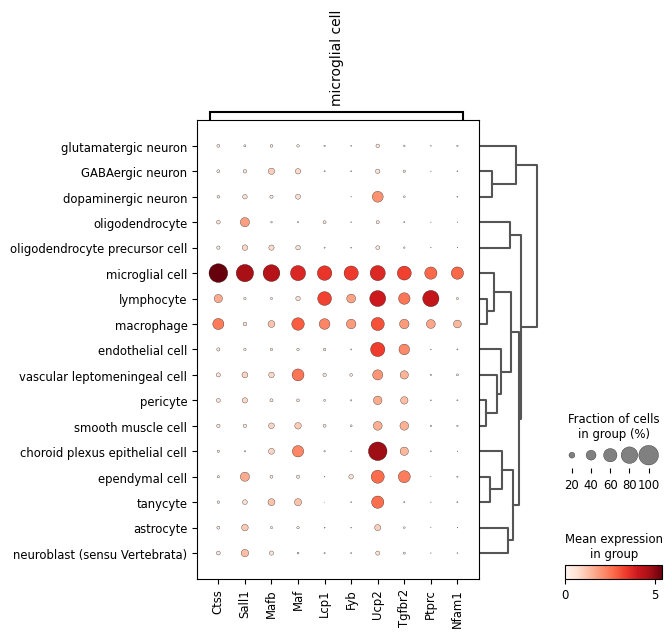

In [36]:
if "log1p" in adata.uns.keys():
    adata.uns.pop("log1p")

sc.tl.rank_genes_groups(
    adata,
    groupby=setup.CELL_TYPE,
    # method="wilcoxon",
    method="t-test",
    key_added="rank_genes_groups",
    pts=True,
    use_raw=False,
    groups=["microglial cell"],
)

sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=setup.CELL_TYPE,
    key="rank_genes_groups",
    # save="nicheVI_rank_genes_groups_dotplot.pdf",
    show=False,
    use_raw=False,
)

In [37]:
sc.get.rank_genes_groups_df(adata, key="rank_genes_groups", group="microglial cell", log2fc_min=2)  # ['names'].tolist()

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Ctss,313.568634,8.811322,0.000000e+00,0.000000e+00,0.937557,0.088203
1,Sall1,180.492828,6.707069,0.000000e+00,0.000000e+00,0.847567,0.147262
2,Mafb,171.303299,7.316932,0.000000e+00,0.000000e+00,0.812672,0.092499
3,Maf,127.332489,6.424363,0.000000e+00,0.000000e+00,0.707530,0.089120
4,Lcp1,123.098175,7.197920,0.000000e+00,0.000000e+00,0.670225,0.043907
5,Fyb,121.767204,8.036407,0.000000e+00,0.000000e+00,0.651286,0.023641
6,Ucp2,105.773506,4.723385,0.000000e+00,0.000000e+00,0.706841,0.195325
7,Tgfbr2,104.371407,5.544081,0.000000e+00,0.000000e+00,0.633724,0.096002
8,Ptprc,96.147751,7.698514,0.000000e+00,0.000000e+00,0.533402,0.014818
9,Nfam1,95.709412,7.139003,0.000000e+00,0.000000e+00,0.537420,0.022228


### CLAUDE

Here is my final list of potential microglia marker genes from the provided list, along with a brief description of each gene:

1. `Ctss` (Cathepsin S) - A lysosomal cysteine protease highly expressed in microglia and involved in antigen presentation and immune responses.

2. `Ptprc` (CD45) - A transmembrane protein tyrosine phosphatase expressed on microglia and other cells of hematopoietic origin, commonly used as a pan-leukocyte marker.

3. `Itga9` (Integrin alpha 9) - An integrin subunit involved in cell-cell and cell-matrix interactions, highly expressed in microglia and implicated in their migration and activation.

4. `Ctsc` (Cathepsin C) - Another lysosomal cysteine protease expressed in microglia and involved in immune functions.

5. `Sall1` (Spalt-Like Transcription Factor 1) - A transcription factor implicated in microglia development and function.

6. `Mafb` (Musculoaponeurotic Fibrosarcoma Oncogene Homolog B) - A transcription factor involved in the regulation of microglia-specific gene expression and function.

7. `Lcp1` (Lymphocyte Cytosolic Protein 1) - A gene involved in T-cell activation and reportedly highly expressed in microglia.

8. `Tgfbr2` (Transforming Growth Factor Beta Receptor 2) - A receptor for TGF-beta, which plays a role in microglia activation and neuroinflammation.

9. `Fli1` (Friend Leukemia Integration 1 Transcription Factor) - A transcription factor involved in the regulation of microglia gene expression and function.

10. `Hpgd` (Hydroxyprostaglandin Dehydrogenase 15-(NAD)) - An enzyme involved in prostaglandin metabolism, which is important for microglia inflammatory responses.

11. `Ets1` (ETS Proto-Oncogene 1, Transcription Factor) - A transcription factor implicated in microglia activation and inflammatory responses.

Please note that while these genes are widely associated with microglia, their expression levels and roles can vary depending on the specific context and experimental conditions. Additionally, some of the other genes in the provided list may also have relevance to microglia biology, although they may not be considered classic microglia markers.


### GPT

Certainly! Here's a bullet list of genes along with their descriptions:

- Ctss: Cathepsin S (Ctss) is a lysosomal cysteine protease involved in antigen presentation and immune responses.
- Sall1: Sall1 is a transcription factor involved in various developmental processes, including kidney and central nervous system development.
- Mafb: Mafb is a transcription factor known to regulate macrophage and microglial development and function.
- Maf: Maf is a transcription factor that plays a role in the regulation of immune responses and inflammation.
- Lcp1: Lcp1 (Lymphocyte cytosolic protein 1) is involved in the regulation of actin dynamics and cell migration, including microglial motility.
- Fyb: Fyb (FYN binding protein) is involved in T cell receptor signaling and could have roles in microglial activation and function.
- Ptprc: Ptprc (Protein tyrosine phosphatase, receptor type C), also known as CD45, is a transmembrane protein tyrosine phosphatase expressed on leukocytes, including microglia.
- Tmem176b: Tmem176b is a transmembrane protein associated with lysosomal function and has been implicated in microglial activation.
- Sall3: Sall3 is a transcription factor involved in neural development and has been reported to be expressed in microglia.
- Tmem176a: Tmem176a is a transmembrane protein expressed in microglia and implicated in lysosomal function and immune responses.

In [38]:
microglia_markers_naive = sc.get.rank_genes_groups_df(
    adata, key="rank_genes_groups", group="microglial cell", log2fc_min=2
)["names"].tolist()

marker_indices_naive = [adata.var_names.get_loc(gene) for gene in microglia_markers_naive if gene in adata.var_names]

microglia_markers_claude = [
    "Ctss",  # Cathepsin S
    "Ptprc",  # CD45
    "Itga9",  # Integrin alpha 9
    "Ctsc",  # Cathepsin C
    "Sall1",  # Spalt-Like Transcription Factor 1
    "Mafb",  # Musculoaponeurotic Fibrosarcoma Oncogene Homolog B
    "Lcp1",  # Lymphocyte Cytosolic Protein 1
    "Tgfbr2",  # Transforming Growth Factor Beta Receptor 2
    "Fli1",  # Friend Leukemia Integration 1 Transcription Factor
    "Hpgd",  # Hydroxyprostaglandin Dehydrogenase 15-(NAD)
    "Ets1",  # ETS Proto-Oncogene 1, Transcription Factor
]

marker_indices_claude = [adata.var_names.get_loc(gene) for gene in microglia_markers_claude if gene in adata.var_names]

microglia_markers_chatgpt = [
    "Ctss",  # Cathepsin S (Ctss) is a lysosomal cysteine protease involved in antigen presentation and immune responses.
    "Sall1",  # Sall1 is a transcription factor involved in various developmental processes, including kidney and central nervous system development.
    "Mafb",  # Mafb is a transcription factor known to regulate macrophage and microglial development and function.
    "Maf",  # Maf is a transcription factor that plays a role in the regulation of immune responses and inflammation.
    "Lcp1",  # Lcp1 (Lymphocyte cytosolic protein 1) is involved in the regulation of actin dynamics and cell migration, including microglial motility.
    "Fyb",  # Fyb (FYN binding protein) is involved in T cell receptor signaling and could have roles in microglial activation and function.
    "Ptprc",  # Ptprc (Protein tyrosine phosphatase, receptor type C), also known as CD45, is a transmembrane protein tyrosine phosphatase expressed on leukocytes, including microglia.
    "Tmem176b",  # Tmem176b is a transmembrane protein associated with lysosomal function and has been implicated in microglial activation.
    "Sall3",  # Sall3 is a transcription factor involved in neural development and has been reported to be expressed in microglia.
    "Tmem176a",  # Tmem176a is a transmembrane protein expressed in microglia and implicated in lysosomal function and immune responses.
]

In [39]:
adata

AnnData object with n_obs × n_vars = 250790 × 1122
    obs: 'organism_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'batch', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'p

In [40]:
microglia_mask = (adata.obs[setup.CELL_TYPE] == "microglial cell").values
nn_matrix = adata.obsm["niche_indexes"]

coord_matrix = adata.obsm[setup.COORDS]

microglia_mask

array([False, False, False, ..., False, False, False])

In [51]:
# vector of ones of the same length as the number of cells

vector_of_ones = np.ones(adata.n_obs)

vector_of_ones

array([1., 1., 1., ..., 1., 1., 1.])

In [5]:
import numpy as np
import pandas as pd

# Assuming you have a list of categories and a list of mask vectors
categories = ["A", "B", "C", "D"]
mask_vectors = [
    np.array([True, False, False, False, True]),
    np.array([False, True, False, False, False]),
    np.array([False, False, False, True, False]),
    np.array([False, False, True, False, False]),
]

# Create a dictionary that maps each category to its mask vector
category_to_mask = dict(zip(categories, mask_vectors))

# Get the number of observations (N)
N = len(mask_vectors[0])

# Create a list of observations (assuming you have a categorical variable)
observations = np.array(["A", "B", "D", "C"])

# Create an empty NxN matrix
matrix = np.zeros((N, N), dtype=bool)

# Build the NxN matrix
category_indices = [list(category_to_mask.keys()).index(obs) for obs in observations]
matrix[np.arange(N)[:, None], category_indices] = True

print(matrix)

[[ True  True  True  True False]
 [ True  True  True  True False]
 [ True  True  True  True False]
 [ True  True  True  True False]
 [ True  True  True  True False]]


In [6]:
df = pd.DataFrame(mask_vectors, index=categories)

df

,0,1,2,3,4
A,True,False,False,False,True
B,False,True,False,False,False
C,False,False,False,True,False
D,False,False,True,False,False


In [7]:
df.loc[["A", "B", "C", "A", "D", "B", "C", "D"]]

,0,1,2,3,4
A,True,False,False,False,True
B,False,True,False,False,False
C,False,False,False,True,False
A,True,False,False,False,True
D,False,False,True,False,False
B,False,True,False,False,False
C,False,False,False,True,False
D,False,False,True,False,False


In [9]:
df.iloc[[0, 1, 2, 0, 3, 1, 2, 3]].values

array([[ True, False, False, False,  True],
       [False,  True, False, False, False],
       [False, False, False,  True, False],
       [ True, False, False, False,  True],
       [False, False,  True, False, False],
       [False,  True, False, False, False],
       [False, False, False,  True, False],
       [False, False,  True, False, False]])

In [41]:
sample_1 = adata.obs[setup.SAMPLE] == "C57BL6J-1.074"

In [42]:
from sklearn.neighbors import NearestNeighbors

k = 5

# Create the NearestNeighbors object and fit it to the data
neigh = NearestNeighbors(n_neighbors=k + 1)  # k+1 to exclude the point itself
neigh.fit(coord_matrix[~microglia_mask])

# Compute the k nearest neighbors for each point
distances, indices = neigh.kneighbors(coord_matrix)

# Convert the indices to the original point indices
knn = indices[:, 1:]  # Exclude the first column (point itself)
knn = np.take_along_axis(np.repeat(np.arange(adata.n_obs)[:, None], k, axis=1), knn, axis=0)

In [43]:
np.max(indices)

242077

In [46]:
indices

array([[     0,     11,     43,     38,     18,     15],
       [     1,      7,     44,    253,     68,    239],
       [     2,     35,     62,     38,     56,     41],
       ...,
       [242075, 242054, 242077, 242048, 242066, 227179],
       [242076, 242031, 242071, 242069, 242072, 242067],
       [242077, 242073, 242048, 242066, 242054, 242075]])

In [47]:
adata.obsm["niche_indexes"]

array([[    12,     46,     41, ...,     21,     43,      9],
       [     7,     47,    270, ...,    261,    303,    259],
       [    38,     66,     41, ...,     54,     68,     50],
       ...,
       [250765, 250789, 250758, ..., 250788, 250786, 250568],
       [250741, 250783, 250781, ..., 250699, 250776, 250785],
       [250785, 250758, 250778, ..., 235273, 250780, 250784]])

In [48]:
import numpy as np

# Assuming adata is your AnnData object and marker_indices_naive are the indices of markers
# adata_markers = adata[:, marker_indices_naive].copy()
adata_markers = adata.copy()

# Get the indices for microglial and non-microglial cells
microglial_indices = adata_markers.obs[setup.CELL_TYPE] == "microglial cell"
non_microglial_indices = ~microglial_indices

# compute the average expression of the markers for cells in the microglial cell group
mean_dict = {
    "uncorrupted_microglia": np.array(adata_markers.layers["uncorrupted_counts"][microglial_indices].mean(axis=0))[0],
    "corrupted_microglia": np.array(adata_markers.layers["corrupted_counts"][microglial_indices].mean(axis=0))[0],
    "uncorrupted_ref:": np.array(adata_markers.layers["uncorrupted_counts"][non_microglial_indices].mean(axis=0))[0],
    "corrupted_ref": np.array(adata_markers.layers["corrupted_counts"][non_microglial_indices].mean(axis=0))[0],
}

# Create a DataFrame
df = pd.DataFrame(mean_dict, index=adata_markers.var_names)
df.T

gene_name,Htr7,Gzmk,Arhgap36,Sema3c,Rxrg,Itga8,Glp2r,Ramp3,Car12,Chn2,...,Galnt14,Kcnh8,Pifo,Epb41l4a,Matn2,Gata3,Fat1,Zim1,Lmo1,Cntnap3
uncorrupted_microglia,0.129497,0.014148,0.067389,0.236823,0.137169,0.019008,0.018993,0.167189,0.080849,0.940664,...,0.094459,0.037146,0.008999,0.054166,0.056881,0.048084,0.286695,0.046592,0.124246,0.034722
corrupted_microglia,0.745116,0.050624,0.307858,1.344187,0.628479,0.203706,0.135776,0.739341,0.455482,1.864378,...,0.714561,0.244381,0.066024,0.360242,0.471680,0.121182,1.600830,0.472442,0.515338,0.292406
uncorrupted_ref:,0.450706,0.021870,0.193519,0.553779,0.340012,0.125055,0.066522,0.402480,0.265359,0.782789,...,0.424090,0.130861,0.045408,0.202910,0.252850,0.043260,0.934617,0.322327,0.223300,0.150625
corrupted_ref,0.976769,0.061462,0.430940,1.389004,0.724257,0.312166,0.180696,0.858084,0.609618,1.688740,...,0.921641,0.344527,0.118326,0.513133,0.613737,0.121404,1.927681,0.684039,0.572901,0.376535


In [49]:
ttest_result = st.ttest_rel(
    a=np.array(adata_markers.layers["uncorrupted_counts"][microglial_indices].toarray()),
    b=np.array(adata_markers.layers["corrupted_counts"][microglial_indices].toarray()),
    alternative="greater",
)

df["pval_mean-exp"] = ttest_result.pvalue

df["adj_pval_mean-exp"] = st.false_discovery_control(ttest_result.pvalue, method="bh")

In [50]:
df[df["uncorrupted_microglia"] > df["corrupted_microglia"]].sort_values(by="adj_pval_mean-exp")

,uncorrupted_microglia,corrupted_microglia,uncorrupted_ref:,corrupted_ref,pval_mean-exp,adj_pval_mean-exp
gene_name,,,,,,
Ctss,6.414453,5.920314,0.368380,1.435016,0.000000e+00,0.000000e+00
Sall1,5.046634,4.784774,0.631353,1.778835,2.561500e-114,1.437001e-111
Mafb,4.677704,4.432577,0.383473,1.288636,7.047299e-99,2.635690e-96
Fyb,3.385187,3.197362,0.092851,0.535657,3.696794e-70,1.036951e-67
Ptprc,2.620777,2.478818,0.059525,0.381385,1.700220e-47,3.815293e-45
Lcp1,3.529787,3.384945,0.180852,0.765748,1.065063e-36,1.991668e-34
Nfam1,2.644690,2.516739,0.087118,0.440657,4.431821e-36,7.103575e-34
Maf,3.892820,3.775568,0.368876,1.147650,3.203910e-22,4.493484e-20
Upk1b,1.037553,1.021577,0.038892,0.188070,1.210392e-02,1.000000e+00


<Axes: >

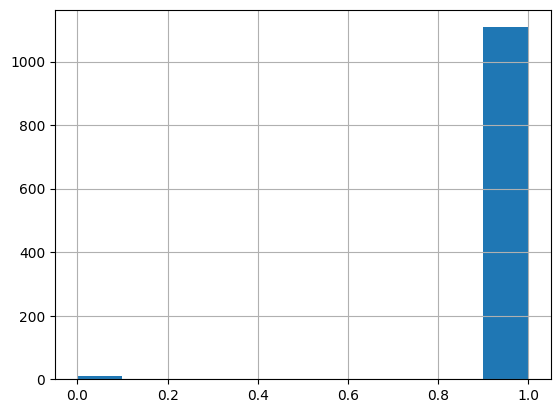

In [47]:
df["pval_mean-exp"].hist()

In [104]:
["Ctss", "Sall1", "Mafb", "Maf", "Lcp1", "Fyb", "Ptprc", "Nfam1", "Blnk", "Upk1b"]

['Ctss',
 'Sall1',
 'Mafb',
 'Maf',
 'Lcp1',
 'Fyb',
 'Ptprc',
 'Nfam1',
 'Blnk',
 'Upk1b']

In [21]:
# sc.get.rank_genes_groups_df(adata, key="rank_genes_groups", group="microglial cell", log2fc_min=2) #['names'].tolist()

# Compare with corrupted counts

# CLUSTER NICHEVI LATENT

In [24]:
nichevi_latent_key = "scvi_r1_kl1_s10_X_nicheVI"
banksy_key = "banksy_pc_20_lambda_0.4"


cell_type_for_study = "microglial cell"
# cell_type_for_study = "macrophage"

leiden_resolution = 0.6

corrupt_counts(
    adata,
    "niche_indexes",
    "niche_distances",
    use_layer="counts",
    save_weights=True,
    bandwidth="median",
    k_nn=5,
    target_sum=1e4,
    spatial_weight=1.0,
    log1p=True,
)

# Select the cell type to analyze
adata_CD4 = adata[adata.obs[setup.CELL_TYPE].isin([cell_type_for_study])].copy()

# Compute the MDEs
adata_CD4.obsm["MDE_CD4_scVI"] = scvi.model.utils.mde(adata_CD4.obsm["X_scVI"])

adata_CD4.obsm["MDE_CD4_nicheVI"] = scvi.model.utils.mde(adata_CD4.obsm[nichevi_latent_key])

adata_CD4.obsm["MDE_CD4_simVI"] = scvi.model.utils.mde(adata_CD4.obsm["simvi_both_08"])

adata_CD4.obsm["MDE_CD4_banksy"] = scvi.model.utils.mde(adata_CD4.obsm[banksy_key])


# LEIDEN
sc.pp.neighbors(adata_CD4, use_rep="X_scVI")
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_scvi")

sc.pp.neighbors(adata_CD4, use_rep="simvi_both_08")
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_simvi")

sc.pp.neighbors(adata_CD4, use_rep=nichevi_latent_key)
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_nichevi")

sc.pp.neighbors(adata_CD4, use_rep=banksy_key)
sc.tl.leiden(adata_CD4, resolution=leiden_resolution, key_added="leiden_banksy")

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              
INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              
INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              
INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


<Axes: >

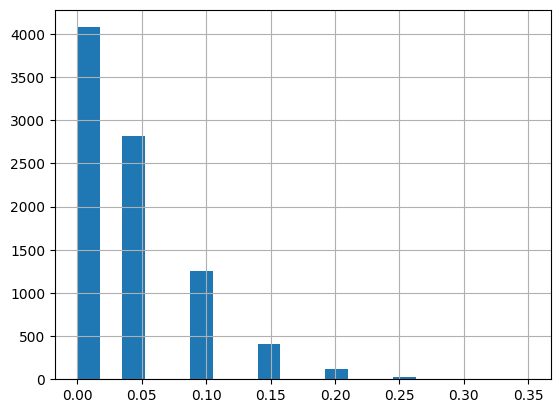

In [27]:
adata_CD4.obsm["neighborhood_composition"]["microglial cell"].hist(bins=20)

In [1]:
from nichevi.spatial_analysis import compute_jaccard

proportions = compute_jaccard(adata_CD4, "leiden_nichevi", setup.NICHE)

/home/nathanlevy/mambaforge/envs/scvi/lib/python3.11/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/nathanlevy/mambaforge/envs/scvi/lib/python3.11/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/nathanlevy/mambaforge/envs/scvi/lib/python3.11/site-packag

NameError: name 'adata_CD4' is not defined

<Figure size 1000x600 with 0 Axes>

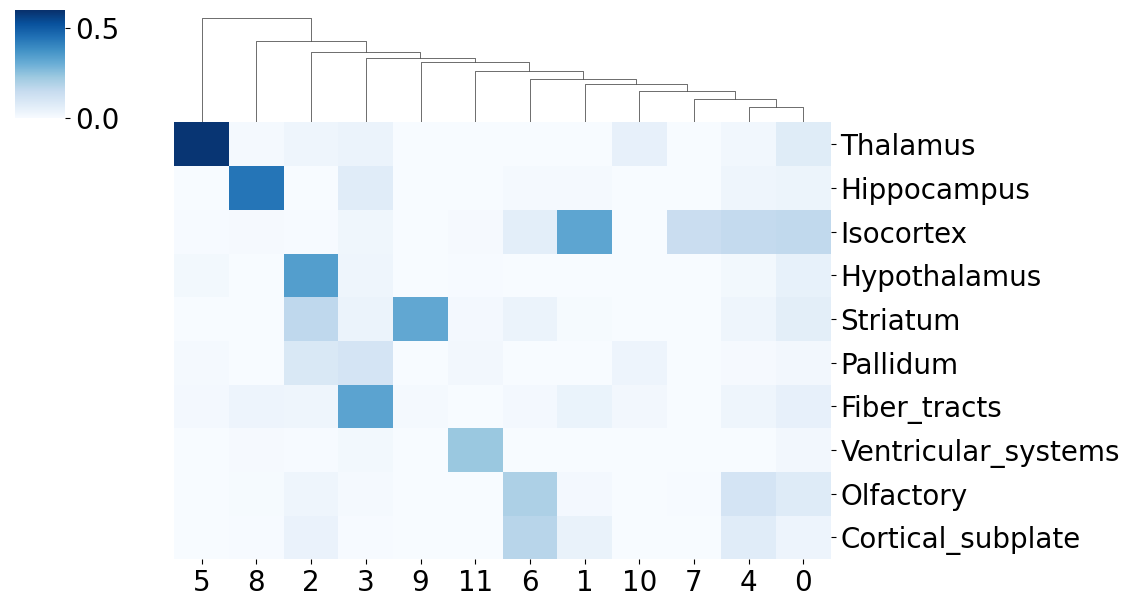

In [29]:
idx = pd.Index(
    [
        "Thalamus",
        "Hippocampus",
        "Isocortex",
        "Hypothalamus",
        "Striatum",
        "Pallidum",
        "Fiber_tracts",
        "Ventricular_systems",
        "Olfactory",
        "Cortical_subplate",
    ],
    dtype="object",
)

fs = 20
CLUSTERMAP = True
plt.figure(figsize=(10, 6))

if CLUSTERMAP:
    fig = sns.clustermap(
        data=proportions.loc[idx],
        cmap="Blues",
        row_cluster=False,
        col_cluster=True,
        annot=False,
        fmt=".2f",
        vmax=0.6,
        figsize=(10, 6),
    )
    # fig.fig.suptitle('Jaccard similarity')
    ax = fig.ax_heatmap

    ax.grid(False)
    # ax.set_xlabel('Samples')
    # ax.set_ylabel('Samples')

else:
    # Create a heatmap
    ax = sns.heatmap(
        proportions.loc[idx],
        annot=False,
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        fmt=".2%",
        annot_kws={"size": 18},
        vmin=0,  # Set minimum colorbar limit
        vmax=0.6,  # Set maximum colorbar limit
    )

# Adjust xticks and yticks fontsize
ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=fs)

# Adjust colorbar fontsize
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fs)

plt.grid(False)
# plt.savefig(f"{figure_dir}clustermap_scvi.png", bbox_inches="tight", dpi=1000)
plt.show()

# MICROGLIA DE

In [49]:
# check if "log1p" is a key in .uns:
if "log1p" in adata_CD4.uns.keys():
    del adata_CD4.uns["log1p"]

sc.tl.rank_genes_groups(
    adata_CD4,
    groupby="leiden_nichevi",
    method="t-test",
    key_added="rank_genes",
    pts=True,
    use_raw=False,
)

sc.tl.rank_genes_groups(
    adata_CD4,
    groupby="leiden_nichevi",
    method="t-test",
    layer="corrupted_counts",
    key_added="rank_genes_corrupted",
    pts=True,
    use_raw=False,
)

CLUSTER = "8"

In [50]:
", ".join(list(adata.var_names))

'Htr7, Gzmk, Arhgap36, Sema3c, Rxrg, Itga8, Glp2r, Ramp3, Car12, Chn2, Endou, Cnih3, Esyt3, Sox6, Kit, Colgalt2, Synpo2, Ntsr1, Nxph3, Brs3, Ddc, Fam43a, Htr1f, Slc5a5, Lemd1, Dcdc2a, Serinc2, Lamb3, Ngf, Trh, Chat, Gpr4, Ngb, Upk1b, Ptger3, Stk32b, Gpr101, Ucma, Fndc1, Sox14, St18, Il31ra, Tcerg1l, Aqp6, Prkd1, Rgs12, Samd3, Col26a1, Moxd1, S1pr1, Tshz1, Grik3, Oprm1, 4930467D21Rik, Adam18, Irx6, Lrp4, Myo3b, Dbh, Onecut3, Slc26a4, Cd34, Padi2, 2610028E06Rik, Chrdl1, D130009I18Rik, Grm8, Bves, Pou4f2, Pde3a, Sox10, Gda, Esr1, Epha10, Trp73, Alox8, Klhdc8a, Gpr149, Nr2e1, 9330158H04Rik, Crispld1, Chrna2, Rcn1, Sec14l5, Lcp1, Ednra, 5830418P13Rik, Serpina9, Pou6f2, Igfbp4, Slc24a4, Lhx4, Hpse2, Gnrh1, Lypd6, Creb5, Rxfp3, Stxbp6, Acsbg1, Arx, Arntl, Tmem200a, Ppp1r1b, Slc35d3, Lama4, Dmrt2, Car3, Gem, Sox9, A730046J19Rik, Nxph2, Ebf3, Mef2c, Kctd8, Ascl1, Shroom3, Lipg, Tnfaip8l3, Oxtr, Tafa4, Tnfrsf8, Zfp831, Lsp1, Isyna1, Slco1c1, Pou3f1, Ccdc3, Rxfp1, Aldh1a3, Nr4a2, Cdkn1a, Bmpr1b, 

In [51]:
# adata[:, 'Trem2'].X.sum()

In [52]:
sc.get.rank_genes_groups_df(adata_CD4, group=CLUSTER, key="rank_genes")

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Gfap,17.432663,3.638020,4.149211e-51,4.655414e-48,0.679144,0.242384
1,Slc17a7,16.903891,3.260994,4.694450e-49,2.633587e-46,0.735294,0.334133
2,Hs3st4,13.424915,3.453835,5.048368e-34,7.080336e-32,0.491979,0.143560
3,Fgf13,10.850757,2.626188,3.592099e-24,3.107502e-22,0.470588,0.185656
4,Ptk2b,10.844228,1.997264,2.664743e-24,2.718038e-22,0.740642,0.486927
...,...,...,...,...,...,...,...
1117,Grm8,-13.620275,-26.656401,8.481379e-42,1.359444e-39,0.000000,0.022068
1118,Dlk1,-13.958727,-26.824671,8.639051e-44,1.615503e-41,0.000000,0.023147
1119,Klf5,-14.156162,-26.821920,5.663963e-45,1.270993e-42,0.000000,0.023867
1120,Col6a1,-14.735487,-26.982027,1.550757e-48,4.349875e-46,0.000000,0.025905


In [53]:
adata_CD4.uns["rank_genes"]["pts"]

,0,1,2,3,4,5,6,7,8,9,10,11
gene_name,,,,,,,,,,,,
Htr7,0.006645,0.021480,0.043721,0.013474,0.019436,0.057214,0.056818,0.093240,0.032086,0.018519,0.000000,0.000000
Gzmk,0.001993,0.003182,0.002791,0.001925,0.003887,0.002488,0.005682,0.002331,0.010695,0.003086,0.000000,0.000000
Arhgap36,0.003987,0.007955,0.082791,0.006737,0.001944,0.003731,0.014205,0.002331,0.002674,0.006173,0.010753,0.012658
Sema3c,0.035880,0.088305,0.050233,0.041386,0.060253,0.039801,0.068182,0.041958,0.045455,0.043210,0.021505,0.075949
Rxrg,0.007973,0.022275,0.071628,0.014437,0.013605,0.011194,0.107955,0.009324,0.005348,0.120370,0.010753,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
Gata3,0.005316,0.014320,0.021395,0.009625,0.009718,0.016169,0.011364,0.009324,0.010695,0.000000,0.021505,0.000000
Fat1,0.018605,0.077168,0.095814,0.104909,0.045675,0.079602,0.086648,0.037296,0.064171,0.064815,0.043011,0.050633
Zim1,0.001329,0.005569,0.050233,0.005775,0.002915,0.003731,0.009943,0.006993,0.010695,0.021605,0.000000,0.000000


In [26]:
sc.get.rank_genes_groups_df(adata_CD4, group="5", key="rank_genes_corrupted")

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Zic1,52.879837,5.446766,5.327656e-289,1.494407e-286,0.945274,0.306904
1,Prkcd,40.586693,5.272461,6.738089e-206,6.300113e-204,0.898010,0.395802
2,Tcf7l2,38.812496,4.402894,1.848279e-195,1.595207e-193,0.911692,0.377719
3,Shox2,35.364952,5.932487,1.281565e-167,5.751665e-166,0.798507,0.081689
4,Grid2ip,34.851055,5.432457,4.700490e-165,1.883553e-163,0.822139,0.136444
...,...,...,...,...,...,...,...
1117,Egr3,-41.857517,-4.273623,2.267729e-278,5.088783e-276,0.099502,0.542742
1118,Pde1a,-42.237885,-4.140984,1.125411e-274,2.104519e-272,0.128109,0.593829
1119,Cckbr,-43.189079,-4.517694,6.538314e-303,2.445329e-300,0.057214,0.511634
1120,Neurod2,-46.532398,-4.773591,0.000000e+00,0.000000e+00,0.072139,0.516945


In [27]:
def compare_de_genes(
    adata: AnnData,
    key_uncorr: str,
    key_corr: str,
    group: str,
    log2fc_min: float | None = None,
    pval_cutoff: float | None = None,
    column_to_compare: str = "logfoldchanges",
    upregulated_in_corrupted: bool = False,
) -> pd.DataFrame:
    gene_df_1 = sc.get.rank_genes_groups_df(
        adata,
        key=key_uncorr,
        group=group,
        log2fc_min=None,
        pval_cutoff=None,
    )
    gene_df_2 = sc.get.rank_genes_groups_df(adata, key=key_corr, group=group, log2fc_min=None, pval_cutoff=None)

    df_compare = pd.merge(
        gene_df_1,
        gene_df_2,
        how="inner",
        on="names",
        suffixes=("_uncorr", "_corr"),
    )

    if upregulated_in_corrupted:
        df_subset = df_compare[df_compare[column_to_compare + "_uncorr"] < df_compare[column_to_compare + "_corr"]]

    else:
        df_subset = df_compare[df_compare[column_to_compare + "_uncorr"] > df_compare[column_to_compare + "_corr"]]

    df_subset = df_subset[df_subset["logfoldchanges_uncorr"] > log2fc_min]  # only positive logfoldchanges

    df_subset = df_subset[df_subset["pvals_adj_uncorr"] < 1e-3]  # only significant genes

    # remove the list of columns

    df_subset = df_subset[
        [
            "names",
            "logfoldchanges_uncorr",
            "logfoldchanges_corr",
            "pvals_adj_uncorr",
            "pvals_adj_corr",
            "pct_nz_group_corr",
            "pct_nz_reference_corr",
            "pct_nz_group_uncorr",
            "pct_nz_reference_uncorr",
        ]
    ]

    # sort by the logfoldchanges_uncorr

    df_subset = df_subset.sort_values(by="logfoldchanges_corr", ascending=False).reset_index(drop=True)

    return df_subset

In [28]:
compare_de_genes(
    adata_CD4,
    "rank_genes",
    "rank_genes_corrupted",
    group=CLUSTER,
    log2fc_min=0.5,
    pval_cutoff=0.5,
    upregulated_in_corrupted=True,
)

,names,logfoldchanges_uncorr,logfoldchanges_corr,pvals_adj_uncorr,pvals_adj_corr,pct_nz_group_corr,pct_nz_reference_corr,pct_nz_group_uncorr,pct_nz_reference_uncorr
0,Lhx2,1.763411,2.035145,2.090748e-09,2.597045e-29,0.877005,0.595586,0.294118,0.134805
1,Ntsr2,1.476170,1.965355,3.618116e-08,6.678279e-22,0.877005,0.704845,0.355615,0.198969
2,Gpr37l1,1.465910,1.788388,1.074111e-07,7.938489e-18,0.842246,0.722595,0.328877,0.181219
3,Thrsp,1.506869,1.730131,2.998590e-08,4.257477e-17,0.716578,0.452147,0.339572,0.182538
4,Gja1,1.717644,1.728390,2.557267e-11,4.087631e-18,0.890374,0.779444,0.427807,0.230751
5,Emx2,1.521535,1.597082,7.673443e-05,2.914909e-15,0.692513,0.403814,0.147059,0.062965
6,Grin2c,1.319491,1.596658,2.728090e-04,1.198742e-13,0.721925,0.529264,0.157754,0.076397
7,Mfge8,1.084417,1.531829,3.395885e-05,1.007957e-15,0.879679,0.796594,0.366310,0.239626
8,Cxcl14,1.390637,1.516239,5.120866e-07,2.843348e-15,0.812834,0.647637,0.318182,0.181219
9,S1pr1,1.084307,1.514261,1.745359e-05,1.065914e-16,0.885027,0.787959,0.427807,0.297314


In [29]:
compare_de_genes(
    adata_CD4,
    "rank_genes",
    "rank_genes_corrupted",
    group=CLUSTER,
    log2fc_min=0.5,
    pval_cutoff=0.05,
    upregulated_in_corrupted=False,
).head(30)

,names,logfoldchanges_uncorr,logfoldchanges_corr,pvals_adj_uncorr,pvals_adj_corr,pct_nz_group_corr,pct_nz_reference_corr,pct_nz_group_uncorr,pct_nz_reference_uncorr
0,Lrrc10b,3.719702,3.326549,2.914466e-19,4.505071e-36,0.660428,0.174622,0.270053,0.037059
1,Gfap,3.638020,2.903284,4.655414e-48,1.992989e-46,0.882353,0.602543,0.679144,0.242384
2,Hopx,3.020439,2.240438,1.355394e-19,1.248585e-25,0.724599,0.371792,0.328877,0.080115
3,Shisa6,2.847588,2.220987,3.367988e-07,2.275631e-17,0.497326,0.242144,0.114973,0.019429
4,Hs3st4,3.453835,1.871264,7.080336e-32,1.276007e-19,0.791444,0.566923,0.491979,0.143560
5,Homer3,2.068887,1.845392,1.596447e-09,7.306587e-14,0.518717,0.221636,0.224599,0.076517
6,C1ql2,2.769812,1.844803,2.001876e-04,1.300893e-07,0.251337,0.130607,0.066845,0.012113
7,Neurod2,2.855201,1.825760,9.666732e-19,5.105357e-17,0.764706,0.462941,0.342246,0.101463
8,Prdm8,2.540779,1.767157,1.242129e-09,5.734716e-14,0.548128,0.327177,0.179144,0.046054
9,Neurod6,3.120802,1.737679,2.741876e-15,1.525308e-13,0.593583,0.344807,0.245989,0.049652


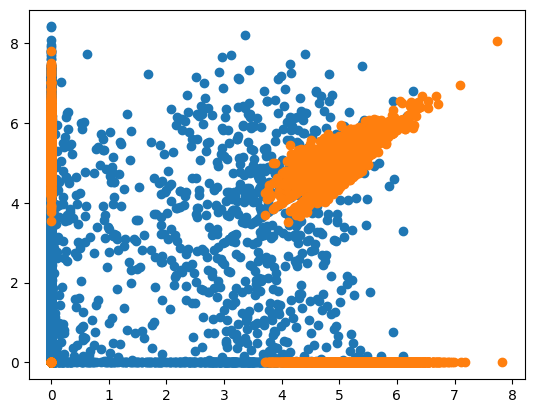

In [30]:
gene_x = "Ptprc"
gene_y = "Gfap"
plt.scatter(
    adata_CD4[:, gene_x].layers["corrupted_counts"].toarray(),
    adata_CD4[:, gene_y].layers["corrupted_counts"].toarray(),
)
plt.scatter(
    adata_CD4[:, gene_x].X.toarray(),
    adata_CD4[:, gene_y].X.toarray(),
)

In [31]:
genes = compare_de_genes(
    adata_CD4,
    "rank_genes",
    "rank_genes_corrupted",
    group=CLUSTER,
    log2fc_min=0.5,
    pval_cutoff=0.05,
    upregulated_in_corrupted=False,
)["names"].to_list()

In [32]:
genes

['Lrrc10b',
 'Gfap',
 'Hopx',
 'Shisa6',
 'Hs3st4',
 'Homer3',
 'C1ql2',
 'Neurod2',
 'Prdm8',
 'Neurod6',
 'Slc17a7',
 'Nr4a3',
 'Bhlhe22',
 'Acsbg1',
 'Arhgef26',
 'Fgf13',
 'Pkp2',
 'Nbl1',
 'St6galnac5',
 'Aldh1l1',
 'Pla2g7',
 'Mdga1',
 'Ust',
 'Sox9',
 'Stac2',
 'Fam107a',
 'Ccdc3',
 'Grik4',
 'Epha7',
 'Tgfbr2',
 'Sall3',
 'Lhfpl2',
 'Nfix',
 'Epha6',
 'Pou3f3',
 'Adora1',
 'Bcl11b',
 'Crym',
 'Serpine2',
 'Zeb2',
 'Ptk2b',
 'Gprc5b',
 'Nfam1',
 'Tal1',
 'Prkcd',
 'Bcl11a',
 'Sla',
 'Epha4',
 'Yif1b',
 'Ucp2',
 'Rreb1',
 'Mafb']

/home/nathanlevy/mambaforge/envs/scvi/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


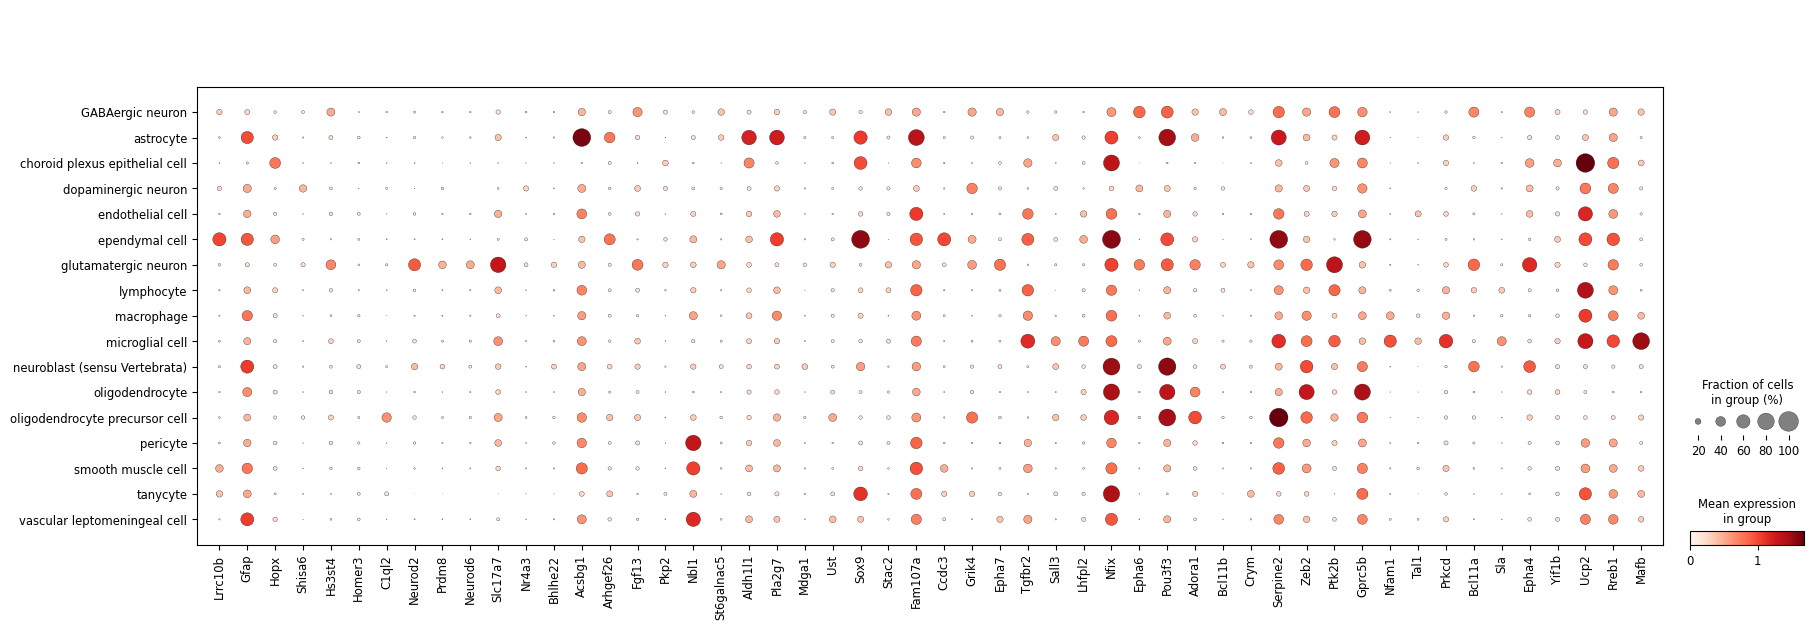

In [33]:
sc.pl.dotplot(adata, genes, groupby=setup.CELL_TYPE, log=True, use_raw=False)

/home/nathanlevy/mambaforge/envs/scvi/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


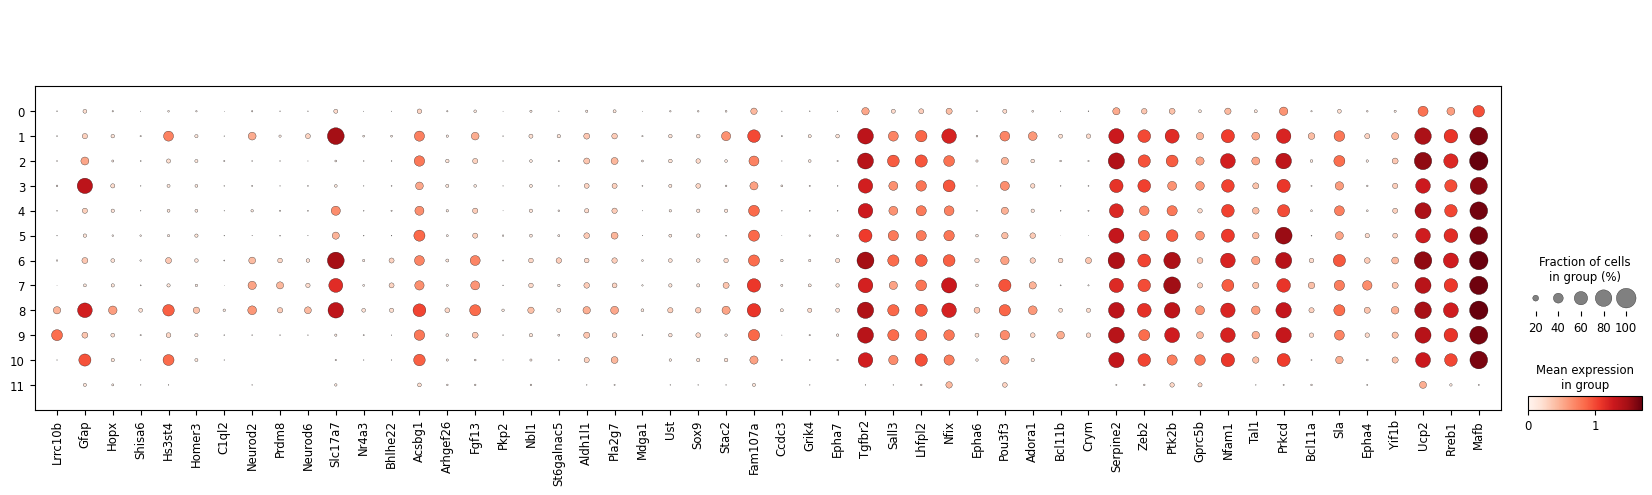

In [34]:
sc.pl.dotplot(adata_CD4, genes, groupby="leiden_nichevi", log=True, use_raw=False)

/home/nathanlevy/mambaforge/envs/scvi/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


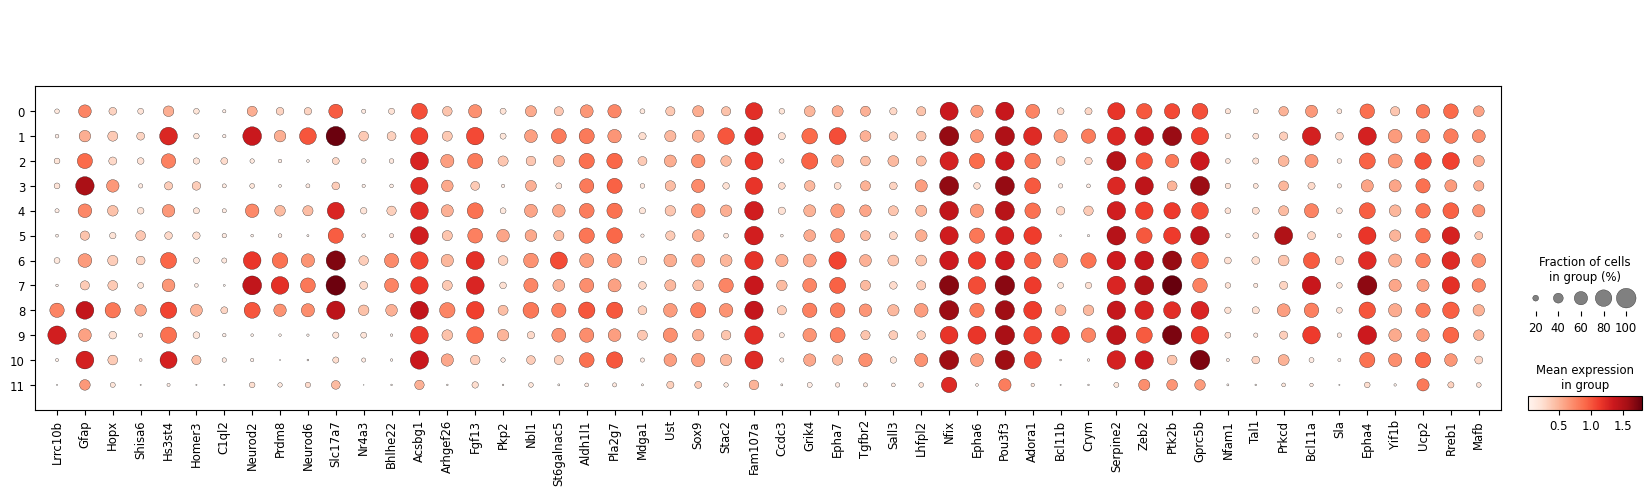

In [35]:
sc.pl.dotplot(
    adata_CD4,
    genes,
    groupby="leiden_nichevi",
    log=True,
    use_raw=False,
    layer="corrupted_counts",
)

In [36]:
genes_5 = sc.get.rank_genes_groups_df(
    adata_CD4,
    key="rank_genes",
    group="5",
    log2fc_min=1,
)

genes_5

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Zic1,23.402760,5.434033,2.477174e-93,5.558778e-91,0.453980,0.037936
1,Nefh,19.981604,3.548657,1.597091e-73,1.378412e-71,0.503731,0.146940
2,Prkcd,17.307770,2.046286,2.779481e-59,1.732543e-57,0.819652,0.591553
3,Shox2,16.594645,6.688653,1.966622e-53,1.050738e-51,0.266169,0.005690
4,Tcf7l2,13.834794,2.501714,1.472014e-39,6.117038e-38,0.396766,0.158194
...,...,...,...,...,...,...,...
119,Epha1,1.201926,1.171361,2.297149e-01,3.953070e-01,0.006219,0.002656
120,Rxfp2,1.178094,1.701262,2.390888e-01,4.083069e-01,0.003731,0.001265
121,Drd5,1.164827,1.111938,2.444065e-01,4.141291e-01,0.006219,0.003161
122,Pax8,1.128242,1.060575,2.595251e-01,4.337201e-01,0.006219,0.003161


In [37]:
genes_5_corrupted = sc.get.rank_genes_groups_df(
    adata_CD4,
    key="rank_genes_corrupted",
    group="5",
    log2fc_min=1,
)

genes_5_corrupted

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Zic1,52.879837,5.446766,5.327656e-289,1.494407e-286,0.945274,0.306904
1,Prkcd,40.586693,5.272461,6.738089e-206,6.300113e-204,0.898010,0.395802
2,Tcf7l2,38.812496,4.402894,1.848279e-195,1.595207e-193,0.911692,0.377719
3,Shox2,35.364952,5.932487,1.281565e-167,5.751665e-166,0.798507,0.081689
4,Grid2ip,34.851055,5.432457,4.700490e-165,1.883553e-163,0.822139,0.136444
...,...,...,...,...,...,...,...
100,Lncenc1,4.817344,1.096429,1.710885e-06,4.032800e-06,0.164179,0.101290
101,Drd5,4.364009,1.136347,1.428120e-05,3.191934e-05,0.135572,0.072838
102,Barhl2,4.110837,1.267267,4.312481e-05,9.164022e-05,0.099502,0.050076
103,St14,3.754457,1.141395,1.851914e-04,3.750628e-04,0.090796,0.055893


In [40]:
set_bn = False
"none" if set_bn else "both"

'both'